# Kreditzinsen in Deutschland vs. EZB-Leitzins (seit 2020)

Vergleich der Effektivzinssätze für Konsumenten- und Unternehmenskredite (Neugeschäft)
mit den EZB-Leitzinsen, auf Basis der offiziellen Bundesbank-Zeitreihen.

**Datenquelle:** Bundesbank SDMX Web Service ([api.statistiken.bundesbank.de](https://api.statistiken.bundesbank.de)) — keine Anmeldung nötig.

**Aufbau:**
1. Setup & Imports
2. Konfiguration der Zeitreihen-IDs
3. Abruf-Funktion (SDMX REST API)
4. Daten abrufen
5. Datenaufbereitung
6. EDA – Zinsentwicklung über Zeit
7. EDA – Vergleich der Kreditarten
8. EDA – Korrelation mit dem Leitzins
9. Star-Schema für Power BI

*Kein ML-Modell — Fokus liegt auf Datenbeschaffung und explorativer Analyse.*

## 1. Setup & Imports

In [1]:
# Benötigte Pakete: pandas, numpy, matplotlib, requests
# pip install pandas numpy matplotlib requests

import io
import re
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

# Farben (validierte dataviz-Palette, konsistent mit dashboard.py)
FARBE_KONSUM = "#2a78d6"
FARBE_UNTERNEHMEN = "#eb6834"
FARBE_DIVERGING = ["#2a78d6", "#f0efec", "#e34948"]  # Blau - Grau - Rot
FARBE_MASKIERT = "#e1e0d9"

## 2. Konfiguration der Zeitreihen-IDs

Alle IDs wurden gegen die aktuelle Bundesbank-API geprüft (Stand: 2026).
Format: `name: (flowRef, seriesKey)`

In [2]:
START_DATE = "2020-01-01"  # Analysezeitraum: seit 2020

SERIES = {
    # --- Konsumentenkredite, Neugeschäft, Effektivzinssatz ---
    "Konsum_gesamt":            ("BBIM1", "M.DE.B.A2B.A.C.A.2250.EUR.N"),
    "Konsum_bis_1J":            ("BBIM1", "M.DE.B.A2B.F.R.A.2250.EUR.N"),
    "Konsum_1_bis_5J":          ("BBIM1", "M.DE.B.A2B.I.R.A.2250.EUR.N"),
    "Konsum_ueber_5J":          ("BBIM1", "M.DE.B.A2B.J.R.A.2250.EUR.N"),

    # --- Unternehmenskredite, Neugeschäft, Effektivzinssatz (gesamt) ---
    "Unternehmen_gesamt":       ("BBIM1", "M.DE.B.A2A.A.R.A.2240.EUR.N"),

    # --- EZB-Leitzinsen (Notenbankzinssätze) ---
    "Hauptrefinanzierungssatz": ("BBIN1", "M.D0.ECB.ECBMIN.EUR.ME"),
    "Einlagefazilitaet":        ("BBIN1", "M.D0.ECB.ECBFAC.EUR.ME"),
    "Spitzenrefinanzierung":    ("BBIN1", "M.D0.ECB.ECBREF.EUR.ME"),
}

## 3. Abruf-Funktion (SDMX REST API)

Bundesbank-CSVs enthalten vor den eigentlichen Daten mehrere Metadaten-Zeilen
(`Dezimalstellen;...`, `Kommentar;...` usw.). Die eigentlichen Datenzeilen erkennt
man am Muster `JJJJ-MM;Wert;` am Zeilenanfang — danach wird eingelesen.
Bei Fehlern (z. B. veraltete ID) wird eine leere Series zurückgegeben — die Ursache
steht in der Ausgabe, sodass einzelne IDs bei Bedarf leicht ersetzt werden können.

In [3]:
DATE_PATTERN = re.compile(r"^\d{4}-\d{2};")

def fetch_bundesbank_series(flow_ref: str, series_key: str, name: str) -> pd.Series:
    """Lädt eine Zeitreihe von der Bundesbank SDMX-API als pandas Series (Datum -> %)."""
    url = f"https://api.statistiken.bundesbank.de/rest/data/{flow_ref}/{series_key}"
    params = {"format": "csv", "lang": "de"}

    try:
        resp = requests.get(url, params=params, timeout=30)
        resp.raise_for_status()
    except requests.RequestException as e:
        print(f"[FEHLER] {name} ({flow_ref}/{series_key}): {e}")
        return pd.Series(dtype=float, name=name)

    raw = resp.content.decode("utf-8-sig", errors="replace")
    lines = raw.splitlines()

    # Metadaten-Kopf überspringen: erste Zeile suchen, die mit "JJJJ-MM;" beginnt
    data_start = next((i for i, l in enumerate(lines) if DATE_PATTERN.match(l)), None)
    if data_start is None:
        print(f"[WARNUNG] {name}: keine Datenzeilen gefunden, Zeitreihe wird übersprungen.")
        return pd.Series(dtype=float, name=name)

    rows = []
    for l in lines[data_start:]:
        parts = l.split(";")
        if len(parts) < 2:
            continue
        rows.append((parts[0].strip('"'), parts[1].strip('"')))

    df = pd.DataFrame(rows, columns=["Zeit", name])
    df["Zeit"] = pd.to_datetime(df["Zeit"], format="%Y-%m", errors="coerce")
    df[name] = df[name].str.replace(",", ".", regex=False)
    df[name] = pd.to_numeric(df[name], errors="coerce")
    df = df.dropna(subset=["Zeit"]).set_index("Zeit")
    series = df[name].dropna()

    print(f"[OK] {name}: {len(series)} Werte geladen ({flow_ref}/{series_key})")
    return series

## 4. Daten abrufen

In [4]:
series_list = [
    fetch_bundesbank_series(flow_ref, key, name)
    for name, (flow_ref, key) in SERIES.items()
]

# Alle Zeitreihen auf gemeinsamem Datumsindex zusammenführen
df_raw = pd.concat(series_list, axis=1, sort=False)
df_raw = df_raw.sort_index()
df_raw.tail()

[OK] Konsum_gesamt: 283 Werte geladen (BBIM1/M.DE.B.A2B.A.C.A.2250.EUR.N)
[OK] Konsum_bis_1J: 283 Werte geladen (BBIM1/M.DE.B.A2B.F.R.A.2250.EUR.N)
[OK] Konsum_1_bis_5J: 283 Werte geladen (BBIM1/M.DE.B.A2B.I.R.A.2250.EUR.N)
[OK] Konsum_ueber_5J: 283 Werte geladen (BBIM1/M.DE.B.A2B.J.R.A.2250.EUR.N)
[OK] Unternehmen_gesamt: 283 Werte geladen (BBIM1/M.DE.B.A2A.A.R.A.2240.EUR.N)
[OK] Hauptrefinanzierungssatz: 333 Werte geladen (BBIN1/M.D0.ECB.ECBMIN.EUR.ME)
[OK] Einlagefazilitaet: 333 Werte geladen (BBIN1/M.D0.ECB.ECBFAC.EUR.ME)
[OK] Spitzenrefinanzierung: 333 Werte geladen (BBIN1/M.D0.ECB.ECBREF.EUR.ME)


,Konsum_gesamt,Konsum_bis_1J,Konsum_1_bis_5J,Konsum_ueber_5J,Unternehmen_gesamt,Hauptrefinanzierungssatz,Einlagefazilitaet,Spitzenrefinanzierung
Zeit,,,,,,,,
2026-05-01,8.53,6.44,6.99,8.89,3.48,2.15,2.00,2.40
2026-06-01,8.35,6.53,6.93,8.74,3.79,2.40,2.25,2.65
2026-07-01,8.58,6.35,7.05,9.00,3.78,2.40,2.25,2.65
2026-08-01,NaN,NaN,NaN,NaN,NaN,2.40,2.25,2.65
2026-09-01,NaN,NaN,NaN,NaN,NaN,2.65,2.50,2.90


## 5. Datenaufbereitung

- Nur Zeitraum ab `START_DATE` behalten
- EZB-Leitzinsen sind Monatsend-Werte -> passen direkt zum monatlichen Index
- Fehlende Monate (z. B. bei Datenlücken) werden nicht künstlich aufgefüllt

In [5]:
df = df_raw.loc[df_raw.index >= START_DATE].copy()

print("Zeitraum:", df.index.min().date(), "bis", df.index.max().date())
print("Fehlende Werte je Spalte:")
df.isna().sum()

Zeitraum: 2020-01-01 bis 2026-09-01
Fehlende Werte je Spalte:


Konsum_gesamt               2
Konsum_bis_1J               2
Konsum_1_bis_5J             2
Konsum_ueber_5J             2
Unternehmen_gesamt          2
Hauptrefinanzierungssatz    0
Einlagefazilitaet           0
Spitzenrefinanzierung       0
dtype: int64

## 6. EDA – Zinsentwicklung über Zeit

Kreditzinsen (Konsum & Unternehmen) im Vergleich zum EZB-Hauptrefinanzierungssatz.

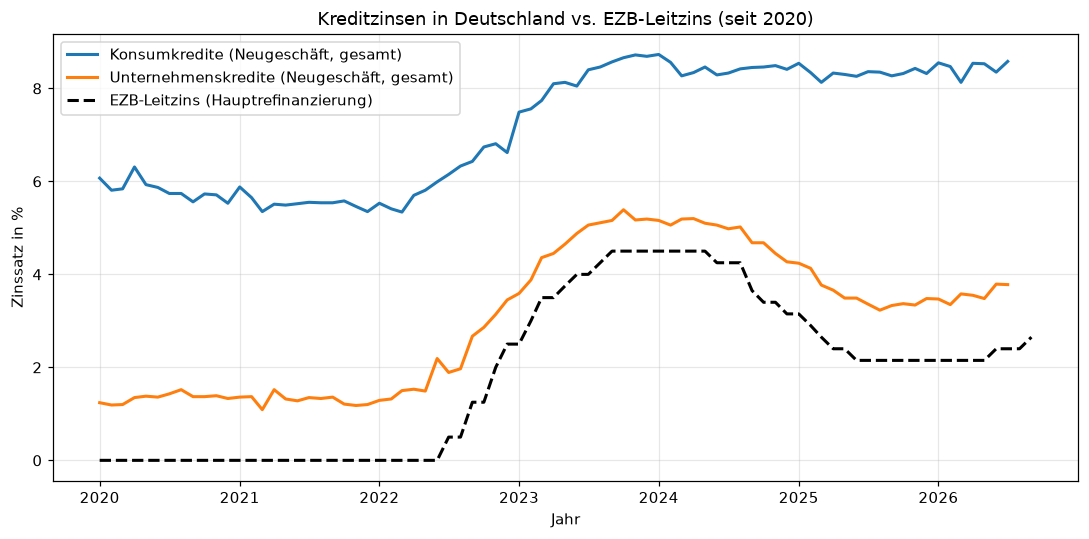

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df.index, df["Konsum_gesamt"], label="Konsumkredite (Neugeschäft, gesamt)", linewidth=2)
ax.plot(df.index, df["Unternehmen_gesamt"], label="Unternehmenskredite (Neugeschäft, gesamt)", linewidth=2)
ax.plot(df.index, df["Hauptrefinanzierungssatz"], label="EZB-Leitzins (Hauptrefinanzierung)",
        linewidth=2, linestyle="--", color="black")

ax.set_title("Kreditzinsen in Deutschland vs. EZB-Leitzins (seit 2020)")
ax.set_ylabel("Zinssatz in %")
ax.set_xlabel("Jahr")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. EDA – Vergleich der Kreditarten

Konsumkredite nach Zinsbindungsdauer (Laufzeit) im Vergleich.

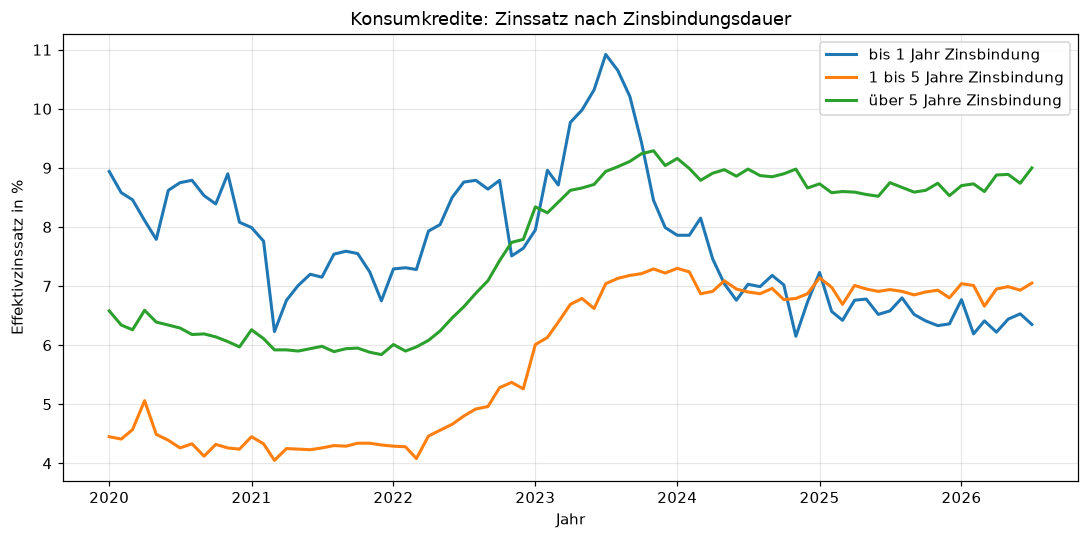

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

laufzeiten = {
    "Konsum_bis_1J": "bis 1 Jahr Zinsbindung",
    "Konsum_1_bis_5J": "1 bis 5 Jahre Zinsbindung",
    "Konsum_ueber_5J": "über 5 Jahre Zinsbindung",
}

for col, label in laufzeiten.items():
    ax.plot(df.index, df[col], label=label, linewidth=2)

ax.set_title("Konsumkredite: Zinssatz nach Zinsbindungsdauer")
ax.set_ylabel("Effektivzinssatz in %")
ax.set_xlabel("Jahr")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. EDA – Korrelation mit dem Leitzins

Korrelationsmatrix aller Zinsreihen + Scatterplot Kreditzins vs. Leitzins.

In [8]:
corr = df.corr()
corr

,Konsum_gesamt,Konsum_bis_1J,Konsum_1_bis_5J,Konsum_ueber_5J,Unternehmen_gesamt,Hauptrefinanzierungssatz,Einlagefazilitaet,Spitzenrefinanzierung
Konsum_gesamt,1.000000,-0.145976,0.996976,0.992336,0.926453,0.905646,0.935698,0.905646
Konsum_bis_1J,-0.145976,1.000000,-0.146036,-0.097144,0.060198,0.076646,0.016511,0.076646
Konsum_1_bis_5J,0.996976,-0.146036,1.000000,0.988304,0.929354,0.911000,0.939702,0.911000
Konsum_ueber_5J,0.992336,-0.097144,0.988304,1.000000,0.950055,0.932153,0.955956,0.932153
Unternehmen_gesamt,0.926453,0.060198,0.929354,0.950055,1.000000,0.993292,0.994643,0.993292
Hauptrefinanzierungssatz,0.905646,0.076646,0.911000,0.932153,0.993292,1.000000,0.995908,1.000000
Einlagefazilitaet,0.935698,0.016511,0.939702,0.955956,0.994643,0.995908,1.000000,0.995908
Spitzenrefinanzierung,0.905646,0.076646,0.911000,0.932153,0.993292,1.000000,0.995908,1.000000


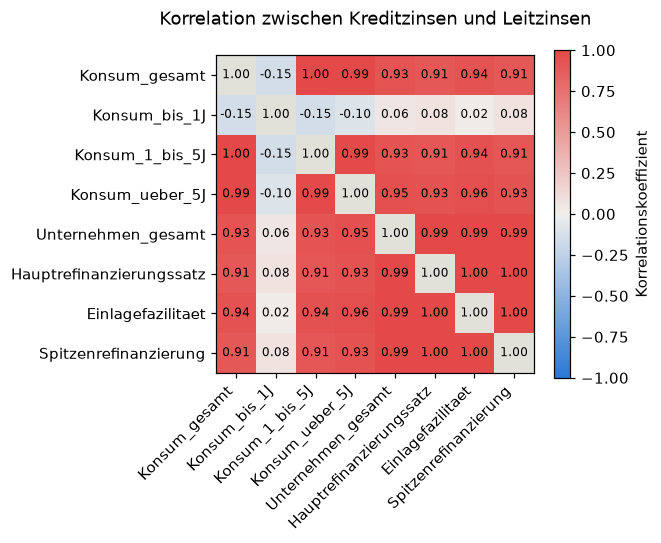

In [9]:
# Diverging Farbskala: Blau (negativ) - Grau (Null) - Rot (positiv)
diverging_cmap = LinearSegmentedColormap.from_list("blue_gray_red", FARBE_DIVERGING)
diverging_cmap.set_bad(color=FARBE_MASKIERT)  # Diagonale (immer 1.00, trivial) grau ausblenden

# Diagonale aus der Farbskalierung ausklammern -> mehr Kontrast im interessanten Bereich
corr_farbe = corr.mask(np.eye(len(corr), dtype=bool))
vmax = corr_farbe.abs().max().max()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_farbe, vmin=-vmax, vmax=vmax, cmap=diverging_cmap)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, label="Korrelationskoeffizient")
ax.set_title("Korrelation zwischen Kreditzinsen und Leitzinsen", pad=20)
plt.tight_layout()
plt.show()

Der Leitzins ändert sich nur selten (bleibt oft monatelang konstant) — im Scatterplot
stapeln sich dadurch viele Punkte exakt übereinander. Kleiner horizontaler Jitter
macht die Punktdichte sichtbar, ohne die eigentlichen Werte zu verfälschen.

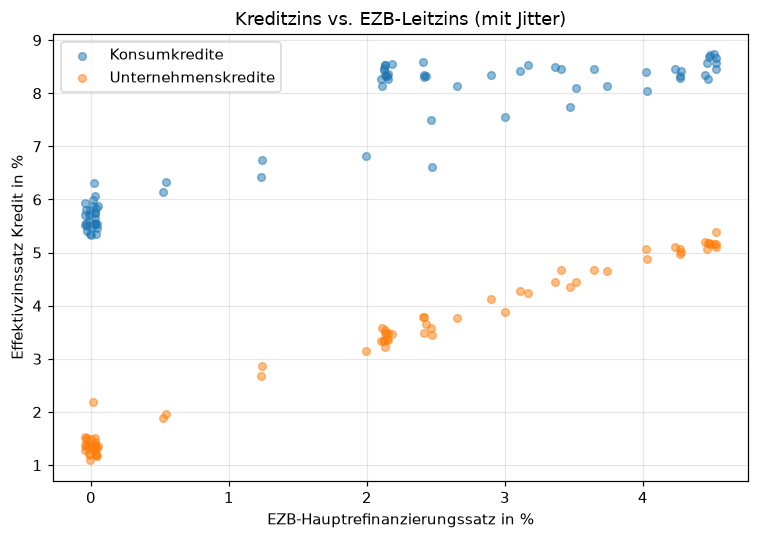

In [10]:
rng = np.random.default_rng(42)  # fester Seed -> reproduzierbarer Jitter
jitter = rng.uniform(-0.05, 0.05, size=len(df))

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df["Hauptrefinanzierungssatz"] + jitter, df["Konsum_gesamt"],
           label="Konsumkredite", alpha=0.5, s=25)
ax.scatter(df["Hauptrefinanzierungssatz"] + jitter, df["Unternehmen_gesamt"],
           label="Unternehmenskredite", alpha=0.5, s=25)

ax.set_title("Kreditzins vs. EZB-Leitzins (mit Jitter)")
ax.set_xlabel("EZB-Hauptrefinanzierungssatz in %")
ax.set_ylabel("Effektivzinssatz Kredit in %")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Alternative Darstellung ohne Überlappungsproblem: Boxplot je Leitzins-Stufe
(Standardansatz, wenn die x-Achse nur wenige diskrete Werte annimmt).

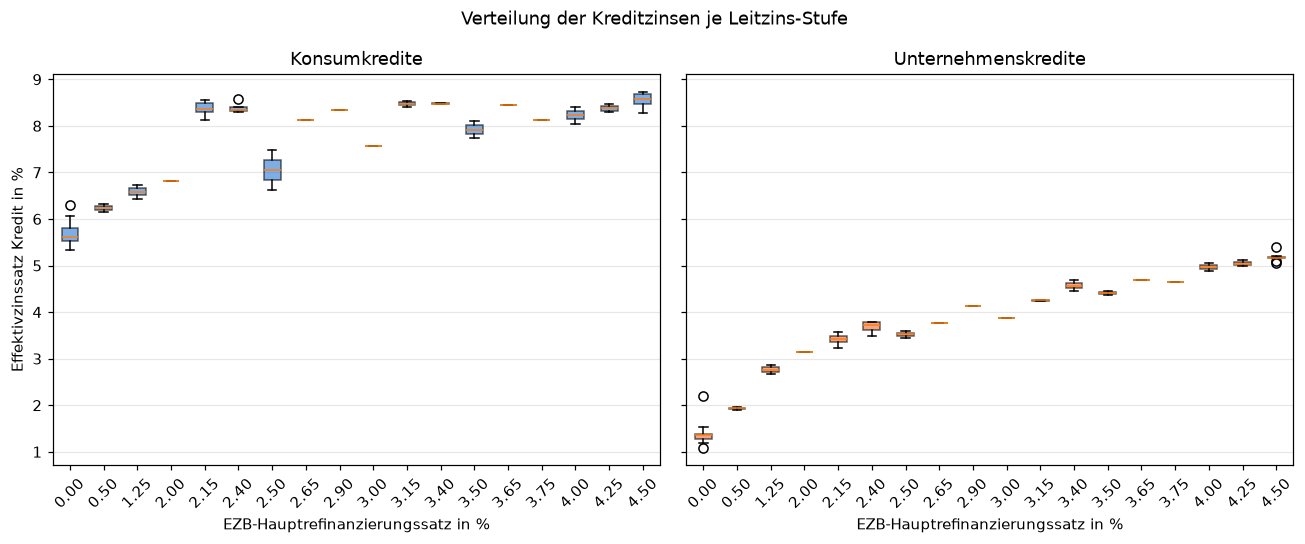

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
leitzins_stufen = sorted(df["Hauptrefinanzierungssatz"].dropna().unique())

plots = [
    ("Konsum_gesamt", "Konsumkredite", FARBE_KONSUM),
    ("Unternehmen_gesamt", "Unternehmenskredite", FARBE_UNTERNEHMEN),
]

for ax, (col, label, color) in zip(axes, plots):
    gruppen = [df.loc[df["Hauptrefinanzierungssatz"] == stufe, col].dropna() for stufe in leitzins_stufen]
    ax.boxplot(gruppen, tick_labels=[f"{s:.2f}" for s in leitzins_stufen],
               patch_artist=True, boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(label)
    ax.set_xlabel("EZB-Hauptrefinanzierungssatz in %")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3, axis="y")

axes[0].set_ylabel("Effektivzinssatz Kredit in %")
fig.suptitle("Verteilung der Kreditzinsen je Leitzins-Stufe")
plt.tight_layout()
plt.show()

## 9. Star-Schema für Power BI

Statt einer breiten Tabelle: 1 Fact-Tabelle + 2 Dimensionstabellen, verbunden über
Surrogate Keys. Damit ist in Power BI keine Power-Query-Nachbearbeitung nötig —
nur die drei CSVs importieren und die Beziehungen über die Keys herstellen.

- **Dim_Zeit**: eine Zeile pro Monat (`Zeit_ID` als Key im Format `JJJJMM`)
- **Dim_Zinsart**: eine Zeile pro Zinsreihe, mit Kategorie (Konsumkredit /
  Unternehmenskredit / Leitzins) und Laufzeit
- **Fact_Zinssaetze**: eine Zeile pro (Monat, Zinsart) — nur tatsächlich vorhandene
  Werte, keine leeren Zeilen für noch nicht veröffentlichte Monate

In [12]:
# --- Dim_Zeit ---
dim_zeit = pd.DataFrame({"Datum": df.index})
dim_zeit["Zeit_ID"] = dim_zeit["Datum"].dt.strftime("%Y%m").astype(int)
dim_zeit["Jahr"] = dim_zeit["Datum"].dt.year
dim_zeit["Quartal"] = dim_zeit["Datum"].dt.quarter
dim_zeit["Monat"] = dim_zeit["Datum"].dt.month
dim_zeit["Jahr_Monat"] = dim_zeit["Datum"].dt.strftime("%Y-%m")
dim_zeit = dim_zeit[["Zeit_ID", "Datum", "Jahr", "Quartal", "Monat", "Jahr_Monat"]]

# --- Dim_Zinsart ---
# (Kategorie, Laufzeit) je Spalte im ursprünglichen breiten DataFrame
zinsart_meta = {
    "Konsum_gesamt":            ("Konsumkredit", "gesamt"),
    "Konsum_bis_1J":            ("Konsumkredit", "bis 1 Jahr"),
    "Konsum_1_bis_5J":          ("Konsumkredit", "1 bis 5 Jahre"),
    "Konsum_ueber_5J":          ("Konsumkredit", "über 5 Jahre"),
    "Unternehmen_gesamt":       ("Unternehmenskredit", "gesamt"),
    "Hauptrefinanzierungssatz": ("Leitzins", "Hauptrefinanzierung"),
    "Einlagefazilitaet":        ("Leitzins", "Einlagefazilität"),
    "Spitzenrefinanzierung":    ("Leitzins", "Spitzenrefinanzierung"),
}

dim_zinsart = pd.DataFrame([
    {"Zinsart_ID": i + 1, "Zinsart_Code": code, "Kategorie": kategorie, "Laufzeit": laufzeit}
    for i, (code, (kategorie, laufzeit)) in enumerate(zinsart_meta.items())
])

# --- Fact_Zinssaetze ---
# Breite Tabelle (df) ins lange Format bringen (unpivot) und Keys zuordnen
fact = df.reset_index().melt(id_vars="Zeit", var_name="Zinsart_Code", value_name="Zinssatz")
fact = fact.dropna(subset=["Zinssatz"])
fact["Zeit_ID"] = fact["Zeit"].dt.strftime("%Y%m").astype(int)
fact = fact.merge(dim_zinsart[["Zinsart_Code", "Zinsart_ID"]], on="Zinsart_Code")
fact_zinssaetze = fact[["Zeit_ID", "Zinsart_ID", "Zinssatz"]].sort_values(["Zeit_ID", "Zinsart_ID"])

print("Dim_Zeit:", dim_zeit.shape)
print("Dim_Zinsart:", dim_zinsart.shape)
print("Fact_Zinssaetze:", fact_zinssaetze.shape)
fact_zinssaetze.head()

Dim_Zeit: (81, 6)
Dim_Zinsart: (8, 4)
Fact_Zinssaetze: (638, 3)


,Zeit_ID,Zinsart_ID,Zinssatz
0,202001,1,6.07
79,202001,2,8.94
158,202001,3,4.45
237,202001,4,6.58
316,202001,5,1.24


In [13]:
dim_zeit.to_csv("dim_zeit.csv", sep=";", index=False, encoding="utf-8-sig")
dim_zinsart.to_csv("dim_zinsart.csv", sep=";", index=False, encoding="utf-8-sig")
fact_zinssaetze.to_csv("fact_zinssaetze.csv", sep=";", decimal=",", index=False, encoding="utf-8-sig")

print("Exportiert: dim_zeit.csv, dim_zinsart.csv, fact_zinssaetze.csv")

Exportiert: dim_zeit.csv, dim_zinsart.csv, fact_zinssaetze.csv
